In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
sns.set_style("whitegrid")

## Tasks

### Task 1: Baseline Model

Start with the simplest approach — a plain linear regression.

1. Load the California Housing dataset:

```python
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target
```

2. Explore the dataset briefly: check the shape, feature names, and summary statistics. What is the target variable (median house value) distribution?
3. Split the data into training and test sets (80/20 split, `random_state=42`).
4. Fit a `LinearRegression` model on the training data.
5. Evaluate on the test set using **MSE**, **RMSE**, **MAE**, and **R²**. Print the results in a clear format.
6. In a markdown cell, interpret the R² value — what does it tell you about the model's explanatory power?





In [2]:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

In [3]:
print("Shape:", X.shape)
print("\nFeature names:", X.columns.tolist())
print("\nSummary statistics:\n", X.describe())

Shape: (20640, 8)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Summary statistics:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861

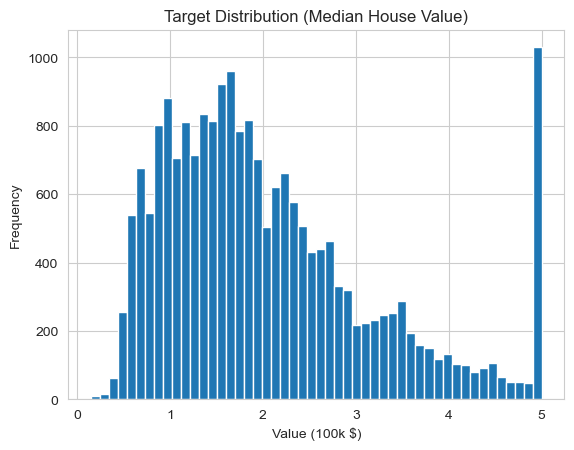

In [4]:
import matplotlib.pyplot as plt

plt.hist(y, bins=50)
plt.title("Target Distribution (Median House Value)")
plt.xlabel("Value (100k $)")
plt.ylabel("Frequency")
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
y_pred = model.predict(X_test)

In [7]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Linear Regression Results ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

=== Linear Regression Results ===
MSE:  0.5559
RMSE: 0.7456
MAE:  0.5332
R²:   0.5758


The R² score is 0.5758, which means the model explains about **57.6% of the variance** in house prices.This indicates that the Linear Regression model captures some of the underlying patterns in the data, but a significant portion (~42.4%) of the variation remains unexplained.In terms of explanatory power, the model is **moderate** — it provides useful predictions, but it is not strong enough to fully represent the complexity of the data, suggesting that more advanced or non-linear models may perform better.

### Task 2: Regularized Regression

Explore how regularization changes the model's behavior.

1. Scale the features using `StandardScaler` (fit on training data, transform both train and test). Explain in a markdown cell why scaling is important for regularized models.
2. Fit **Ridge** regression for alpha values `[0.01, 0.1, 1, 10, 100]`. Record the test R² for each.
3. Fit **Lasso** regression for the same alpha values. Record the test R² for each.
4. Create a plot showing **coefficients vs. alpha** for both Ridge and Lasso (side by side or overlaid). What happens to the coefficients as alpha increases? Which features does Lasso zero out first?
5. Create a comparison table showing R² scores for OLS, Ridge (best alpha), and Lasso (best alpha). Which regularization approach works best here?


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Scaling is important for regularized models like Ridge and Lasso because these models
penalize large coefficients. If features are on different scales, the penalty will
affect them unevenly, causing the model to behave incorrectly. StandardScaler ensures
all features have mean 0 and variance 1, making regularization fair across features.

In [9]:
alphas = [0.01, 0.1, 1, 10, 100]
ridge_results = []
lasso_results = []
for alpha in alphas:
    ridge=Ridge(alpha=alpha).fit(X_train_scaled, y_train)
    ridge_results.append(ridge.score(X_test_scaled,y_test))

    lasso=Lasso(alpha=alpha).fit(X_train_scaled, y_train)
    lasso_results.append(lasso.score(X_test_scaled,y_test))
print("Ridge Scores:", ridge_results)
print("Lasso Scores:", lasso_results)

Ridge Scores: [0.57578798731216, 0.5757905180002314, 0.5758157428913684, 0.5760599032848372, 0.5777912763033605]
Lasso Scores: [0.5816154300698727, 0.48136113250290735, -0.00021908714592466794, -0.00021908714592466794, -0.00021908714592466794]


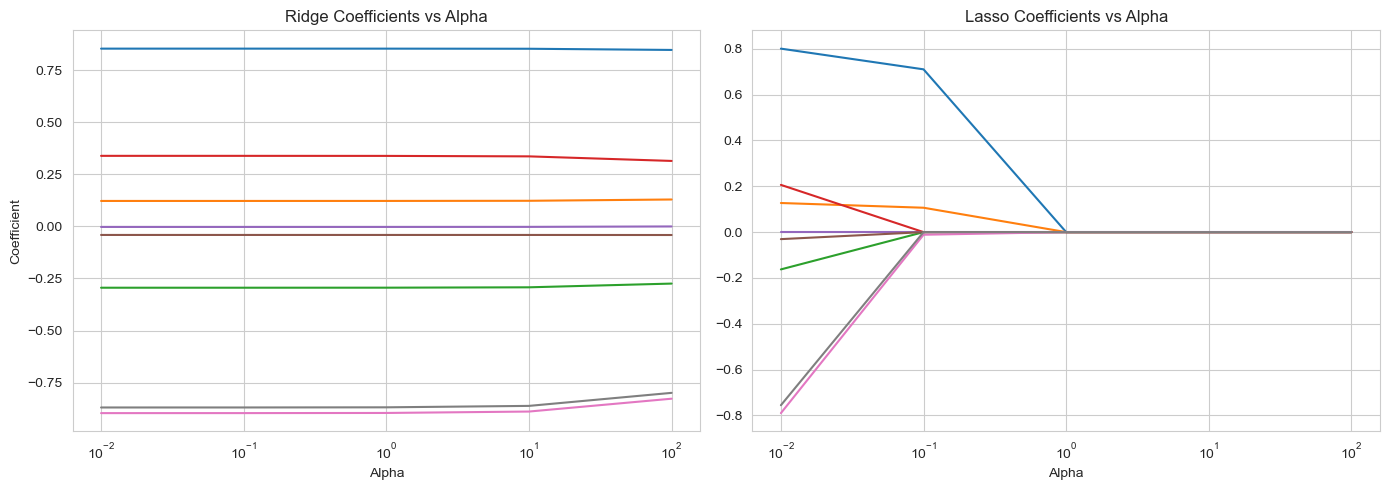

Ridge Scores: [0.57578798731216, 0.5757905180002314, 0.5758157428913684, 0.5760599032848372, 0.5777912763033605]
Lasso Scores: [0.5816154300698727, 0.48136113250290735, -0.00021908714592466794, -0.00021908714592466794, -0.00021908714592466794]


In [10]:
import numpy as np
import matplotlib.pyplot as plt

ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

for i in range(ridge_coefs.shape[1]):
    axes[0].plot(alphas, ridge_coefs[:, i])
axes[0].set_xscale('log')
axes[0].set_title("Ridge Coefficients vs Alpha")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("Coefficient")


for i in range(lasso_coefs.shape[1]):
    axes[1].plot(alphas, lasso_coefs[:, i])
axes[1].set_xscale('log')
axes[1].set_title("Lasso Coefficients vs Alpha")
axes[1].set_xlabel("Alpha")

plt.tight_layout()
plt.show()

print("Ridge Scores:", ridge_results)
print("Lasso Scores:", lasso_results)

From the plots, we can observe that:

- In Ridge regression, coefficients decrease gradually as alpha increases, but none of them become exactly zero. This means Ridge keeps all features while reducing their impact.

- In Lasso regression, coefficients shrink much faster and many of them become exactly zero. This indicates that Lasso performs feature selection by removing less important features.

- As alpha increases, Lasso becomes too aggressive and removes almost all features, leading to underfitting.

- Features with the smallest coefficients are the first to be eliminated by Lasso.

In [11]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
ols_score = ols.score(X_test_scaled, y_test)

best_ridge_idx = ridge_results.index(max(ridge_results))
best_ridge_alpha = alphas[best_ridge_idx]
best_ridge_score = ridge_results[best_ridge_idx]

best_lasso_idx = lasso_results.index(max(lasso_results))
best_lasso_alpha = alphas[best_lasso_idx]
best_lasso_score = lasso_results[best_lasso_idx]

df = pd.DataFrame({
    "Model": [
        "OLS",
        f"Ridge (alpha={best_ridge_alpha})",
        f"Lasso (alpha={best_lasso_alpha})"
    ],
    "R² Score": [
        ols_score,
        best_ridge_score,
        best_lasso_score
    ]
})

df

,Model,R² Score
0,OLS,0.575788
1,Ridge (alpha=100),0.577791
2,Lasso (alpha=0.01),0.581615


From the results:

- OLS achieved an R² score of 0.5758
- Ridge (alpha=100) slightly improved performance to 0.5778
- Lasso (alpha=0.01) achieved the best performance with an R² score of 0.5816

This indicates that a small amount of regularization improves model performance.

Lasso performs best in this case because it is able to eliminate less important features, reducing noise and improving generalization.

However, from the coefficient plots, we observed that Lasso becomes unstable for larger alpha values and quickly removes too many features, leading to underfitting.

Ridge, on the other hand, provides more stable performance across different alpha values, making it a safer choice when model stability is important.


### Task 3: Support Vector Regression

Try a non-linear approach with SVR.

1. Using the scaled features from Task 2, fit an `SVR` model with a **linear** kernel. Report the test R².
2. Fit SVR with an **rbf** kernel. Try at least three values of `C` (e.g., 0.1, 1, 10) and two values of `epsilon` (e.g., 0.1, 0.2). Report the best combination.
3. Fit SVR with a **poly** kernel (degree 2 and 3). Compare with rbf.
4. In a markdown cell, discuss: How does SVR compare to the linear models? Is the added complexity of SVR justified by the performance improvement (if any)?

> **Note:** SVR can be slow on larger datasets. If training takes too long, consider using a random subsample (e.g., 5,000 rows) for the SVR experiments.


In [12]:
svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train_scaled, y_train)

linear_score = svr_linear.score(X_test_scaled, y_test)
print("SVR (Linear) R2:", linear_score)

SVR (Linear) R2: 0.557942737316715


In [13]:
results=[]
for c in [0.1,1,10]:
    for eps in [0.1,0.2]:
        svr_rbf=SVR(kernel='rbf',C=c,epsilon=eps)
        svr_rbf.fit(X_train_scaled,y_train)

        score = svr_rbf.score(X_train_scaled, y_train) 
        results.append((score, c, eps))

best = max(results)

print("Best params (train):", best)

Best params (train): (0.7809089582685889, 10, 0.2)


In [14]:
best_svr = SVR(kernel='rbf', C=best[1], epsilon=best[2])
best_svr.fit(X_train_scaled, y_train)

test_score = best_svr.score(X_test_scaled, y_test)

print("Final Test R2:", test_score)

Final Test R2: 0.7548300537835648


In [15]:
poly_results = {}

for degree in [2, 3]:
    svr_poly = SVR(kernel='poly', degree=degree)
    svr_poly.fit(X_train_scaled, y_train)
    
    score = svr_poly.score(X_test_scaled, y_test)
    poly_results[degree] = score
    
    print(f"SVR Poly (degree={degree}):", score)

SVR Poly (degree=2): -0.05628086558322165
SVR Poly (degree=3): 0.23329856108997982


In [16]:
print("RBF R2:", best[0])
print("Poly deg2 R2:", poly_results[2])
print("Poly deg3 R3:", poly_results[3])

best_value = max(best[0], poly_results[2], poly_results[3])

if best_value == best[0]:
    print("Best: RBF")
elif best_value == poly_results[2]:
    print("Best: Polynomial (degree=2)")
else:
    print("Best: Polynomial (degree=3)")

RBF R2: 0.7809089582685889
Poly deg2 R2: -0.05628086558322165
Poly deg3 R3: 0.23329856108997982
Best: RBF


From the results:

- SVR with a linear kernel achieved an R² of about **0.56**, which is close to the performance of linear models (OLS, Ridge, Lasso ~0.57–0.58). This shows that linear models can only capture linear relationships in the data.
- Polynomial SVR performed poorly:
  - Degree 2 gave a **negative R²**, indicating very poor performance.
  - Degree 3 improved slightly (~0.23) but is still much worse than linear models.
- SVR with an RBF kernel performed the best, with a **train R² ≈ 0.78** and **test R² ≈ 0.75**.



- The poor results of polynomial models suggest that the data does not follow a simple polynomial pattern.
- The strong performance of RBF shows that there are **complex non-linear relationships** in the dataset.
- Linear models are not able to capture these complex patterns, which limits their performance.



The improvement from ~0.58 (linear models) to ~0.75 (RBF SVR) is significant. Therefore, the added complexity of SVR is justified, since it provides much better predictions for this dataset.

### Task 4: Model Comparison

Bring everything together in a final analysis.

1. Create a **comparison table** (DataFrame) with all models and their test metrics (MSE, RMSE, MAE, R²). Include: LinearRegression, best Ridge, best Lasso, and best SVR.
2. Create a **predicted vs. actual** scatter plot for your best-performing model. Add a diagonal reference line (perfect prediction). How well does the model track the true values?
3. Create a **residual plot** (residuals vs. predicted values) for the best model. Do you see any patterns? What would a random scatter indicate?
4. Write a markdown conclusion: Which model performs best and why? What are the trade-offs between model complexity and performance? If you were deploying one of these models, which would you choose?


In [17]:
lr = LinearRegression().fit(X_train_scaled, y_train)
ridge = Ridge(alpha=best_ridge_alpha).fit(X_train_scaled, y_train)
lasso = Lasso(alpha=best_lasso_alpha).fit(X_train_scaled, y_train)
svr = SVR(kernel='rbf', C=best[1], epsilon=best[2]).fit(X_train_scaled, y_train)

def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

models = {
    "LinearRegression": lr.predict(X_test_scaled),
    "Ridge": ridge.predict(X_test_scaled),
    "Lasso": lasso.predict(X_test_scaled),
    "SVR (RBF)": svr.predict(X_test_scaled)
}

data = []

for name, pred in models.items():
    data.append([name, *get_metrics(y_test, pred)])

df = pd.DataFrame(data, columns=["Model", "MSE", "RMSE", "MAE", "R"])
df

,Model,MSE,RMSE,MAE,R
0,LinearRegression,0.555892,0.745581,0.533200,0.575788
1,Ridge,0.553266,0.743819,0.533014,0.577791
2,Lasso,0.548255,0.740442,0.535326,0.581615
3,SVR (RBF),0.321273,0.566809,0.379624,0.754830


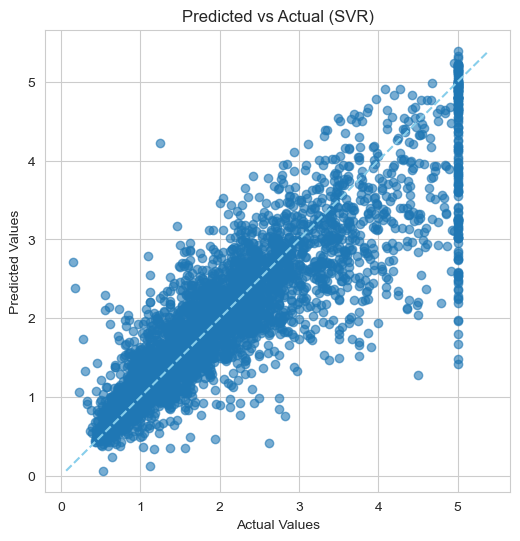

In [18]:
svr_pred = svr.predict(X_test_scaled)
plt.figure(figsize=(6,6))

plt.scatter(y_test, svr_pred, alpha=0.6)
min_val = min(y_test.min(), svr_pred.min())
max_val = max(y_test.max(), svr_pred.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         linestyle='--',color='skyblue')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual (SVR)")

plt.grid(True)

plt.show()

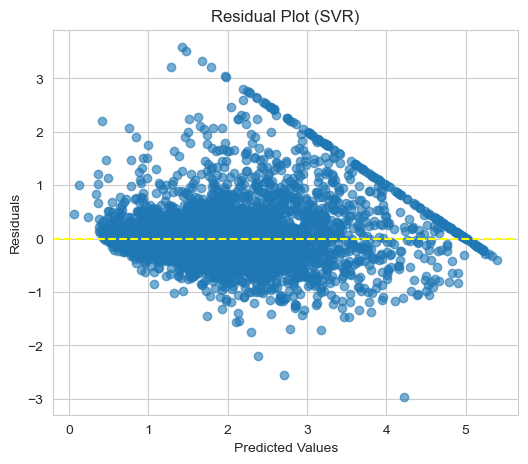

In [19]:
plt.figure(figsize=(6,5))

residuals = y_test - svr_pred

plt.scatter(svr_pred, residuals, alpha=0.6)

plt.axhline(y=0, linestyle='--',color='yellow')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (SVR)")

plt.grid(True)

plt.show()

The residuals are partially randomly distributed around zero, which indicates that the model performs reasonably well.

However, there are visible patterns and increasing spread at higher predicted values, suggesting heteroscedasticity and that the model does not fully capture all underlying relationships.

Among all models, SVR with the RBF kernel performs the best, achieving the highest R² and lowest error values. This indicates that it is able to capture complex non-linear relationships in the data better than linear models.

Linear models (LinearRegression, Ridge, Lasso) are simpler and more interpretable, but their performance is limited because they can only model linear relationships. They are faster and easier to understand, but less accurate in this case.

SVR is more complex and computationally expensive, but it provides significantly better performance. However, it is harder to interpret and may be sensitive to parameter tuning.

Trade-offs

- Linear models:
  - Pros: simple, fast, interpretable
  - Cons: cannot capture complex patterns

- SVR:
  - Pros: higher accuracy, captures non-linearity
  - Cons: more complex, slower, less interpretable

Deployment Choice

If the goal is maximum predictive performance, SVR (RBF) would be the best choice.

If interpretability, speed, or simplicity are more important, Ridge or Lasso could be preferred.

In this case, since the performance improvement is significant, SVR would be the preferred model for deployment.